# Wide vs Deep Neural Networks

**Learning Objectives:**
- Understand the Universal Approximation Theorem and its implications
- Compare wide (shallow) and deep neural network architectures
- Discover why depth provides practical advantages over width
- Explore loss landscapes and feature hierarchies in deep networks

![](media/meme_loss_curve.jpg)

![](media/loss-curve.png)

[ref: Visualizing the Loss Landscape of Neural Nets](https://arxiv.org/pdf/1712.09913)

## Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Using device: cpu


## 1. Motivation: The Architectural Dilemma

Imagine you need to build a neural network with approximately **1 million parameters**. You have two options:

1. **Wide Network**: One hidden layer with ~1000 neurons
2. **Deep Network**: Five hidden layers with ~100 neurons each

Both approaches give you similar parameter counts, but which one should you choose?

Let's start with a surprising theoretical result that might make you think width is enough...

## 2. The Universal Approximation Theorem

### What Does It Say?

The **Universal Approximation Theorem** (Cybenko, 1989; Hornik et al., 1989) states:

> *A neural network with just **one hidden layer** containing a finite number of neurons can approximate any continuous function to arbitrary accuracy (given enough neurons).*

### Breaking It Down

This means that theoretically:
- **Single hidden layer is enough** for any problem
- You only need to make it **wide enough** (add more neurons)
- Deep networks (multiple layers) aren't mathematically necessary

### The Critical Question

If one layer is theoretically sufficient, **why do we use deep networks everywhere?**

The theorem tells us what's **theoretically possible**, not what's **practically efficient**. It's like saying you could dig a tunnel through a mountain with a spoon—technically possible, but there are much better tools!

Let's explore why depth matters in practice.

## 3. Visualizing Wide vs Deep Architectures

Let's create side-by-side diagrams to see the structural difference between wide and deep networks.

![](media/widevsdeep.png)

### Key Observations

- **Wide Network**: Transforms input directly to a high-dimensional representation in one step
- **Deep Network**: Progressively transforms the representation through multiple stages
- Both can have similar parameter counts, but the **computation flow** is fundamentally different

## 4. Comparing Wide vs Deep: A Practical Example

Let's test both architectures on a real task. We'll use a complex function approximation problem to see which architecture learns more efficiently.

In [4]:
# Generate a complex synthetic dataset
def generate_complex_function_data(n_samples=2000):
    """
    Generate data from a complex non-linear function.
    This mimics a hierarchical pattern (like edges -> shapes -> objects).
    """
    X = np.random.uniform(-3, 3, (n_samples, 2))
    
    # Complex hierarchical function
    # Level 1: Simple features
    feat1 = np.sin(X[:, 0])
    feat2 = np.cos(X[:, 1])
    
    # Level 2: Combinations
    feat3 = feat1 * feat2
    feat4 = np.sin(feat1 + feat2)
    
    # Level 3: Higher-order patterns
    y = np.sin(feat3 * 2) + np.cos(feat4 * 3) + 0.1 * np.random.randn(n_samples)
    
    return torch.FloatTensor(X), torch.FloatTensor(y).unsqueeze(1)

# Generate training and test data
X_train, y_train = generate_complex_function_data(1500)
X_test, y_test = generate_complex_function_data(500)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Input features: {X_train.shape[1]}")
print(f"Output dimension: {y_train.shape[1]}")

Training samples: 1500
Test samples: 500
Input features: 2
Output dimension: 1


### Define Wide and Deep Architectures

In [28]:
class WideNetwork(nn.Module):
    """Wide network: 1 large hidden layer."""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(WideNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        return self.network(x)

class DeepNetwork(nn.Module):
    """Deep network: 5 smaller hidden layers."""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(DeepNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        return self.network(x)

# Create networks with similar parameter counts
input_dim = 2
output_dim = 1

# Wide: 1 hidden layer with 128 neurons
wide_net = WideNetwork(input_dim, 1028, output_dim).to(device)

# Deep: 5 hidden layers with 32 neurons each
deep_net = DeepNetwork(input_dim, 32, output_dim).to(device)

# Count parameters
wide_params = sum(p.numel() for p in wide_net.parameters())
deep_params = sum(p.numel() for p in deep_net.parameters())

print(f"\n📊 Network Comparison:")
print(f"Wide Network: {wide_params:,} parameters (1 hidden layer, 1028 neurons)")
print(f"Deep Network: {deep_params:,} parameters (5 hidden layers, 32 neurons each)")
print(f"\nParameter ratio: {wide_params/deep_params:.2f}x")


📊 Network Comparison:
Wide Network: 4,113 parameters (1 hidden layer, 1028 neurons)
Deep Network: 4,353 parameters (5 hidden layers, 32 neurons each)

Parameter ratio: 0.94x


### Training Function

In [29]:
def train_network(model, train_loader, test_loader, epochs=100, lr=0.001):
    """
    Train a network and track training dynamics.
    
    Returns:
        train_losses: Training loss per epoch
        test_losses: Test loss per epoch
        gradient_norms: Average gradient magnitude per epoch
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    test_losses = []
    gradient_norms = []
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0
        epoch_grad_norm = 0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            # Forward pass
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            
            # Track gradient magnitude
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    total_norm += p.grad.data.norm(2).item() ** 2
            total_norm = total_norm ** 0.5
            epoch_grad_norm += total_norm
            
            optimizer.step()
            epoch_train_loss += loss.item()
        
        # Test phase
        model.eval()
        epoch_test_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                epoch_test_loss += loss.item()
        
        # Record metrics
        train_losses.append(epoch_train_loss / len(train_loader))
        test_losses.append(epoch_test_loss / len(test_loader))
        gradient_norms.append(epoch_grad_norm / len(train_loader))
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], "
                  f"Train Loss: {train_losses[-1]:.4f}, "
                  f"Test Loss: {test_losses[-1]:.4f}")
    
    return train_losses, test_losses, gradient_norms

### Train Both Networks

In [30]:
print("🔷 Training Wide Network...")
wide_train_loss, wide_test_loss, wide_grad_norms = train_network(
    wide_net, train_loader, test_loader, epochs=100
)

print("\n🔶 Training Deep Network...")
deep_train_loss, deep_test_loss, deep_grad_norms = train_network(
    deep_net, train_loader, test_loader, epochs=100
)

🔷 Training Wide Network...
Epoch [20/100], Train Loss: 0.0774, Test Loss: 0.0853
Epoch [40/100], Train Loss: 0.0495, Test Loss: 0.0539
Epoch [60/100], Train Loss: 0.0502, Test Loss: 0.0496
Epoch [80/100], Train Loss: 0.0390, Test Loss: 0.0397
Epoch [100/100], Train Loss: 0.0293, Test Loss: 0.0346

🔶 Training Deep Network...
Epoch [20/100], Train Loss: 0.0303, Test Loss: 0.0342
Epoch [40/100], Train Loss: 0.0154, Test Loss: 0.0207
Epoch [60/100], Train Loss: 0.0136, Test Loss: 0.0206
Epoch [80/100], Train Loss: 0.0139, Test Loss: 0.0196
Epoch [100/100], Train Loss: 0.0134, Test Loss: 0.0144


### Visualize Training Dynamics

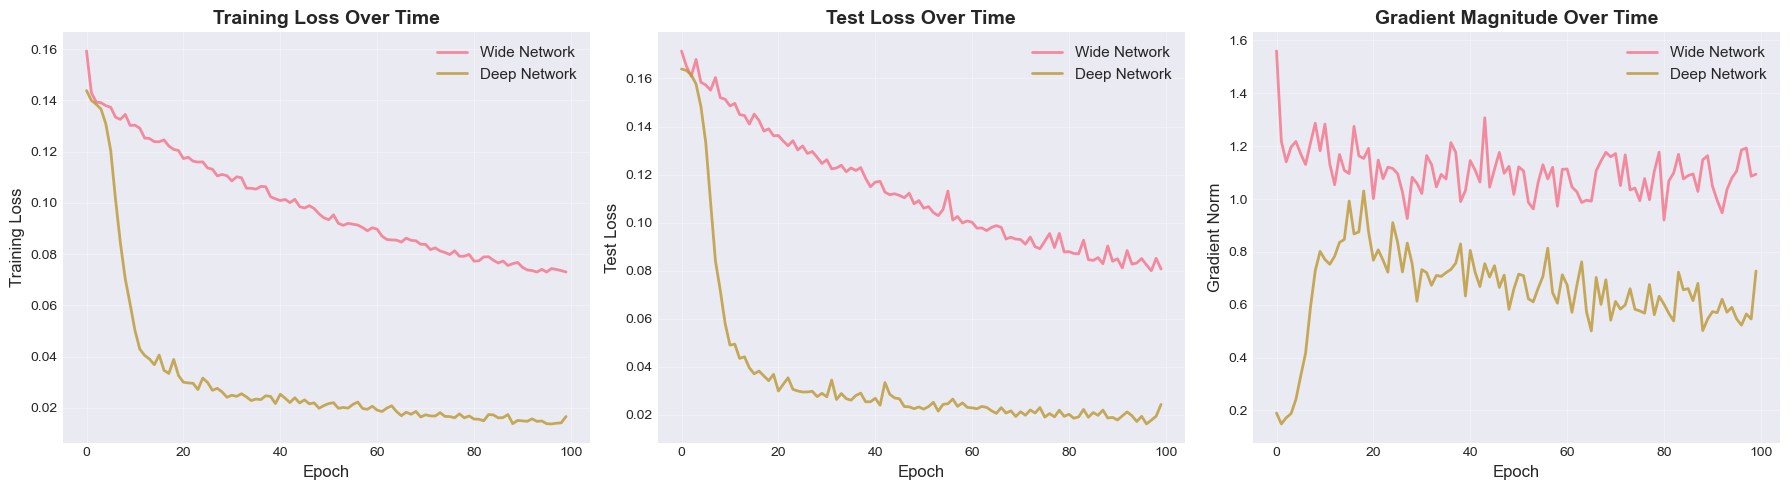


✅ Final Results:
Wide Network - Final Test Loss: 0.0807
Deep Network - Final Test Loss: 0.0243

🎯 Winner: Deep Network


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training loss comparison
axes[0].plot(wide_train_loss, label='Wide Network', linewidth=2, alpha=0.8)
axes[0].plot(deep_train_loss, label='Deep Network', linewidth=2, alpha=0.8)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Training Loss', fontsize=12)
axes[0].set_title('Training Loss Over Time', fontsize=14, weight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Test loss comparison
axes[1].plot(wide_test_loss, label='Wide Network', linewidth=2, alpha=0.8)
axes[1].plot(deep_test_loss, label='Deep Network', linewidth=2, alpha=0.8)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Test Loss', fontsize=12)
axes[1].set_title('Test Loss Over Time', fontsize=14, weight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# Gradient magnitude comparison
axes[2].plot(wide_grad_norms, label='Wide Network', linewidth=2, alpha=0.8)
axes[2].plot(deep_grad_norms, label='Deep Network', linewidth=2, alpha=0.8)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Gradient Norm', fontsize=12)
axes[2].set_title('Gradient Magnitude Over Time', fontsize=14, weight='bold')
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Final Results:")
print(f"Wide Network - Final Test Loss: {wide_test_loss[-1]:.4f}")
print(f"Deep Network - Final Test Loss: {deep_test_loss[-1]:.4f}")
print(f"\n🎯 Winner: {'Deep Network' if deep_test_loss[-1] < wide_test_loss[-1] else 'Wide Network'}")

### 🔧 Mini-Exercise: Experiment with Architecture

**TODO**: Modify the network architectures above and observe what happens:

1. Try making the wide network even wider (e.g., 256 neurons)
2. Try making the deep network even deeper (e.g., 7-8 layers)
3. Keep the total parameter count roughly similar

**What to observe**: 
- Does the very wide network catch up to the deep network?
- Do very deep networks continue to improve?
- What happens to training stability?

⏱️ ~10 minutes

## 5. Why Prefer Deep Networks? Reason 1: Smoother Loss Landscapes

One major advantage of deep networks is that they tend to have **smoother loss landscapes** with **fewer local minima**.

### Understanding Loss Landscapes

The **loss landscape** is a visualization of how the loss function changes as we vary the network parameters. Think of it as a mountainous terrain where:
- **Valleys** = Low loss (good solutions)
- **Peaks** = High loss (bad solutions)
- **Local minima** = Small valleys that trap optimization

### Why Are Deep Networks Smoother?

**Wide networks** often have:
- Many sharp local minima (like a bumpy terrain)
- Harder for gradient descent to find good solutions
- More sensitive to initialization

**Deep networks** tend to have:
- Smoother landscapes with fewer sharp minima
- Easier for gradient descent to navigate
- Better generalization properties

Let's visualize this concept!

In [17]:
def sample_loss_landscape(model, data_loader, param1_range, param2_range, n_points=30):
    """
    Sample the loss landscape by perturbing two random parameter directions.
    This is a simplified 2D projection of the high-dimensional loss landscape.
    """
    criterion = nn.MSELoss()
    
    # Get current parameters
    original_params = [p.clone() for p in model.parameters()]
    
    # Create two random directions for perturbation
    direction1 = [torch.randn_like(p) for p in model.parameters()]
    direction2 = [torch.randn_like(p) for p in model.parameters()]
    
    # Normalize directions
    norm1 = sum((d**2).sum() for d in direction1).sqrt()
    norm2 = sum((d**2).sum() for d in direction2).sqrt()
    direction1 = [d / norm1 for d in direction1]
    direction2 = [d / norm2 for d in direction2]
    
    # Sample loss landscape
    alpha_values = np.linspace(param1_range[0], param1_range[1], n_points)
    beta_values = np.linspace(param2_range[0], param2_range[1], n_points)
    
    loss_grid = np.zeros((n_points, n_points))
    
    for i, alpha in enumerate(alpha_values):
        for j, beta in enumerate(beta_values):
            # Perturb parameters
            for p, p_orig, d1, d2 in zip(model.parameters(), original_params, direction1, direction2):
                p.data = p_orig + alpha * d1 + beta * d2
            
            # Calculate loss
            model.eval()
            total_loss = 0
            with torch.no_grad():
                for batch_X, batch_y in data_loader:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                    total_loss += loss.item()
            
            loss_grid[i, j] = total_loss / len(data_loader)
    
    # Restore original parameters
    for p, p_orig in zip(model.parameters(), original_params):
        p.data = p_orig
    
    return alpha_values, beta_values, loss_grid

In [31]:
print("🔍 Sampling loss landscapes (this may take a minute)...\n")

# Sample loss landscapes around trained parameters
param_range = (-0.5, 0.5)
alpha_w, beta_w, loss_grid_wide = sample_loss_landscape(
    wide_net, test_loader, param_range, param_range, n_points=25
)

alpha_d, beta_d, loss_grid_deep = sample_loss_landscape(
    deep_net, test_loader, param_range, param_range, n_points=25
)

print("✅ Loss landscapes sampled!")

🔍 Sampling loss landscapes (this may take a minute)...

✅ Loss landscapes sampled!


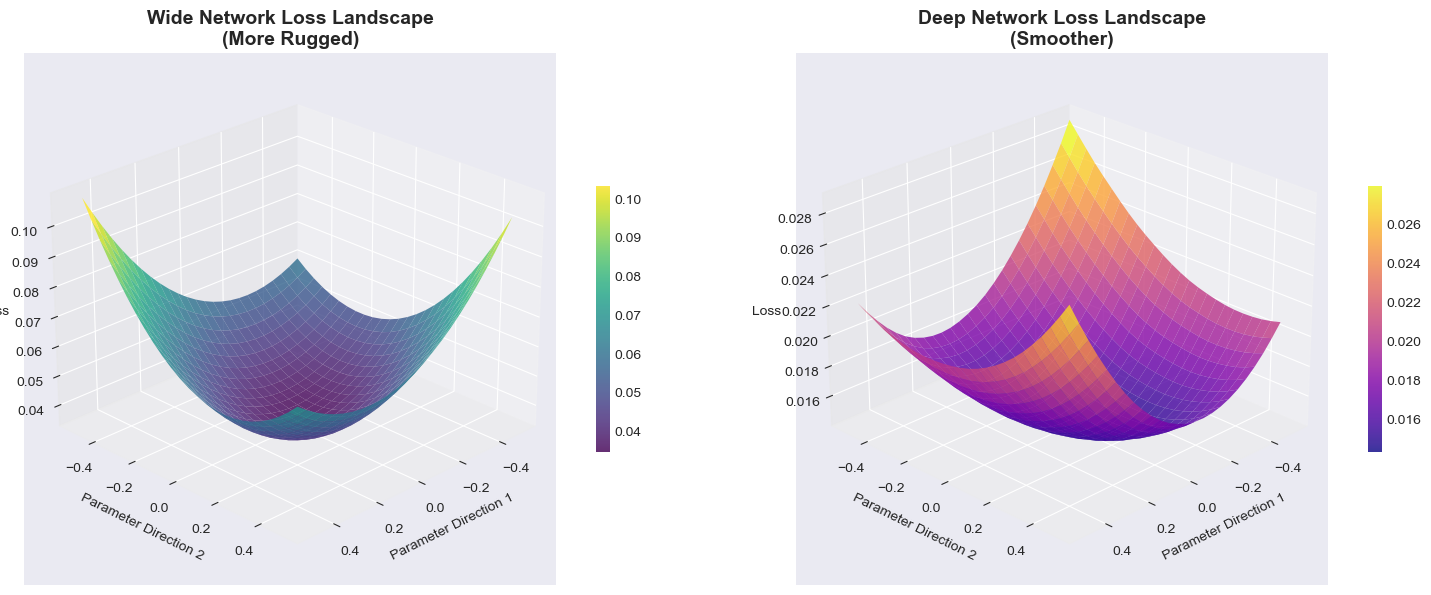


📊 Landscape Roughness Comparison:
Wide Network: 0.0028 (higher = more rugged)
Deep Network: 0.0006 (lower = smoother)

💡 The deep network has a 4.72x smoother landscape!


In [32]:
# Visualize loss landscapes
fig = plt.figure(figsize=(16, 6))

# Wide network landscape
ax1 = fig.add_subplot(121, projection='3d')
X_w, Y_w = np.meshgrid(alpha_w, beta_w)
surf1 = ax1.plot_surface(X_w, Y_w, loss_grid_wide.T, cmap='viridis', alpha=0.8)
ax1.set_xlabel('Parameter Direction 1', fontsize=10)
ax1.set_ylabel('Parameter Direction 2', fontsize=10)
ax1.set_zlabel('Loss', fontsize=10)
ax1.set_title('Wide Network Loss Landscape\n(More Rugged)', fontsize=14, weight='bold')
ax1.view_init(elev=25, azim=45)
fig.colorbar(surf1, ax=ax1, shrink=0.5)

# Deep network landscape
ax2 = fig.add_subplot(122, projection='3d')
X_d, Y_d = np.meshgrid(alpha_d, beta_d)
surf2 = ax2.plot_surface(X_d, Y_d, loss_grid_deep.T, cmap='plasma', alpha=0.8)
ax2.set_xlabel('Parameter Direction 1', fontsize=10)
ax2.set_ylabel('Parameter Direction 2', fontsize=10)
ax2.set_zlabel('Loss', fontsize=10)
ax2.set_title('Deep Network Loss Landscape\n(Smoother)', fontsize=14, weight='bold')
ax2.view_init(elev=25, azim=45)
fig.colorbar(surf2, ax=ax2, shrink=0.5)

plt.tight_layout()
plt.show()

# Calculate landscape roughness (variance of gradients)
wide_roughness = np.std(np.gradient(loss_grid_wide))
deep_roughness = np.std(np.gradient(loss_grid_deep))

print(f"\n📊 Landscape Roughness Comparison:")
print(f"Wide Network: {wide_roughness:.4f} (higher = more rugged)")
print(f"Deep Network: {deep_roughness:.4f} (lower = smoother)")
print(f"\n💡 The deep network has a {wide_roughness/deep_roughness:.2f}x smoother landscape!")

### Key Insights: Loss Landscape Smoothness

1. **Smoother landscapes = Easier optimization**: Gradient descent navigates smoothly toward good solutions
2. **Fewer bad local minima**: Deep networks have fewer "traps" that prevent finding good solutions
3. **Better generalization**: Smoother landscapes correlate with better test performance
4. **More stable training**: Less sensitivity to learning rate and initialization

This is why modern deep learning uses networks with 10s or even 100s of layers!

## 6. Why Prefer Deep Networks? Reason 2: Feature Hierarchy

Perhaps the most important advantage of deep networks is their ability to learn **hierarchical feature representations**.

### The Hierarchy Concept

Consider how humans recognize objects:
1. **Layer 1**: Detect edges and simple patterns
2. **Layer 2**: Combine edges into shapes (corners, curves)
3. **Layer 3**: Combine shapes into parts (wheels, windows, doors)
4. **Layer 4**: Combine parts into objects (car, house, person)
5. **Layer 5**: Understand context and relationships

**Deep networks naturally learn this hierarchy!** Each layer builds on previous layers' features.

**Wide networks** must learn everything in one step—like trying to recognize a car directly from pixels without understanding edges, shapes, or parts.

### The Power of Compositionality

Deep networks leverage **compositionality**: complex functions **can be efficiently represented** by composing many simple operations.

**Example**: To represent a function with $2^n$ regions:
- **Wide network**: Needs $O(2^n)$ neurons (exponential!)
- **Deep network**: Needs only $O(n)$ neurons per layer (linear!)

This is called the **exponential advantage of depth**.

### Visualizing Feature Hierarchy

Let's examine what each layer in our deep network learns.

In [33]:
def get_layer_activations(model, input_data):
    """
    Extract activations from each layer of a deep network.
    """
    activations = []
    
    def hook_fn(module, input, output):
        activations.append(output.detach().cpu().numpy())
    
    # Register hooks for each layer
    hooks = []
    for layer in model.network:
        if isinstance(layer, nn.Linear):
            hooks.append(layer.register_forward_hook(hook_fn))
    
    # Forward pass
    model.eval()
    with torch.no_grad():
        _ = model(input_data.to(device))
    
    # Remove hooks
    for hook in hooks:
        hook.remove()
    
    return activations

# Get activations for a batch of test data
sample_batch = X_test[:100]
deep_activations = get_layer_activations(deep_net, sample_batch)

print(f"Number of layers in deep network: {len(deep_activations)}")
print(f"Activation shape per layer:")
for i, act in enumerate(deep_activations):
    print(f"  Layer {i+1}: {act.shape}")

Number of layers in deep network: 6
Activation shape per layer:
  Layer 1: (100, 32)
  Layer 2: (100, 32)
  Layer 3: (100, 32)
  Layer 4: (100, 32)
  Layer 5: (100, 32)
  Layer 6: (100, 1)


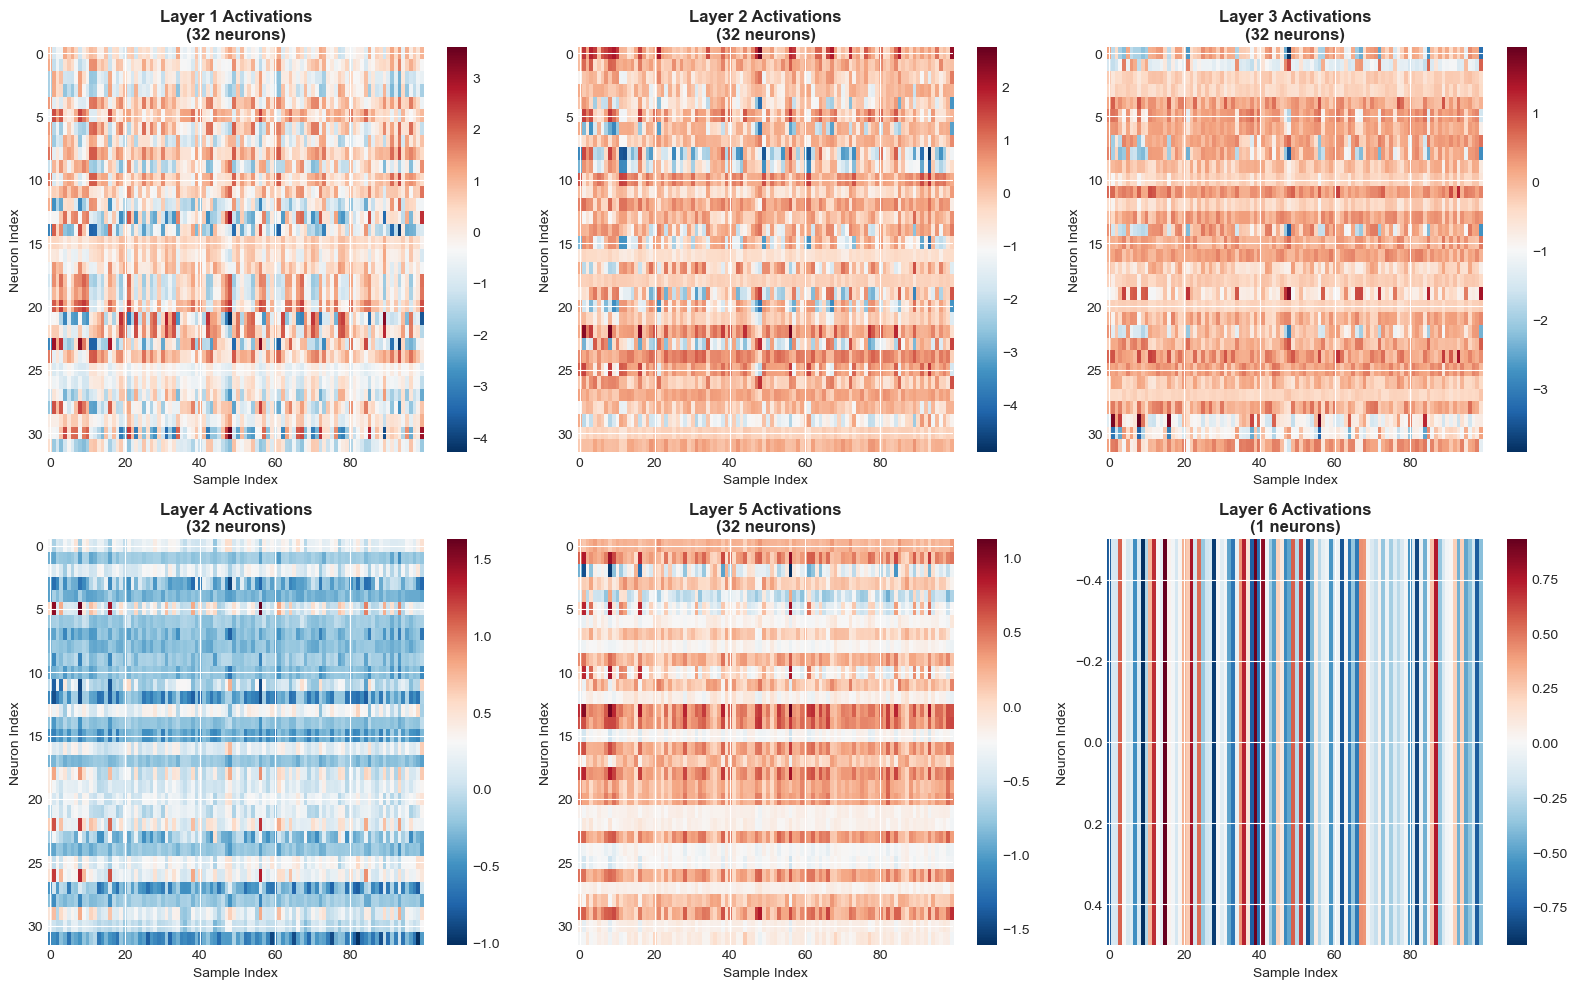


🔍 What to notice:
- Early layers: More varied activation patterns (learning basic features)
- Middle layers: More structured patterns (combining features)
- Later layers: More specialized patterns (high-level representations)

💡 Each layer builds on the previous one's representations!


In [34]:
# Visualize activation patterns across layers
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, act in enumerate(deep_activations):
    if i >= 6:  # Only plot first 6 layers
        break
    
    # Show activation heatmap
    im = axes[i].imshow(act.T, aspect='auto', cmap='RdBu_r', interpolation='nearest')
    axes[i].set_title(f'Layer {i+1} Activations\n({act.shape[1]} neurons)', 
                      fontsize=12, weight='bold')
    axes[i].set_xlabel('Sample Index', fontsize=10)
    axes[i].set_ylabel('Neuron Index', fontsize=10)
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.show()

print("\n🔍 What to notice:")
print("- Early layers: More varied activation patterns (learning basic features)")
print("- Middle layers: More structured patterns (combining features)")
print("- Later layers: More specialized patterns (high-level representations)")
print("\n💡 Each layer builds on the previous one's representations!")

### 🔧 Mini-Exercise: Explore Feature Hierarchy

**TODO**: Investigate how different inputs activate different layers:

1. Create two very different input samples (e.g., opposite corners of input space)
2. Compare their activation patterns across layers
3. Which layers show the most difference? Which show the least?

**Hint**: Use `get_layer_activations()` on different inputs and compare the results.

**What to discover**: 
- Do early layers treat different inputs similarly or differently?
- Do later layers create more separation between different inputs?

⏱️ ~10 minutes

1

## 7. Summary: Why Deep Networks Win

Let's recap the key insights:

### 🎯 Universal Approximation Theorem
- One hidden layer is theoretically sufficient to approximate any function
- **BUT**: "Sufficient" doesn't mean "practical" or "efficient"

### ✅ Advantages of Deep Networks

**1. Smoother Loss Landscapes**
- Fewer sharp local minima
- Easier optimization with gradient descent
- More stable training
- Better generalization

**2. Feature Hierarchy**
- Automatically learn compositional representations
- Build from simple features → complex patterns
- **Exponential representational efficiency**: represent $2^n$ patterns with $O(n)$ parameters
- Mirror how humans understand the world

**3. Parameter Efficiency**
- Deep networks achieve better performance with similar or fewer parameters
- More expressive per parameter than wide networks

**4. Inductive Bias**
- The hierarchical structure acts as an inductive bias
- Guides learning toward compositional solutions
- Natural fit for real-world data (images, language, audio)

### 📊 Rule of Thumb

When designing architectures:
- **Prefer depth over width** for most problems
- Use width to increase capacity within a layer
- Balance depth and width based on your compute budget
- Very deep networks (50+ layers) may need special techniques (skip connections, normalization)

### 🎓 Historical Note

This understanding drove the "deep learning revolution" of the 2010s:
- 2012: AlexNet (8 layers) dominated ImageNet
- 2015: ResNet (152 layers) achieved human-level image classification
- Today: Transformers use 100+ layers for language understanding

**The key insight**: Going deeper, not wider, unlocked AI's potential.

## 8. Final Exercise: Design Your Own Architecture

**🎯 Challenge**: You have a budget of **5,000 parameters**. Design two networks:

1. A wide network (1-2 hidden layers)
2. A deep network (5+ hidden layers)

Train both on our complex function dataset and compare:
- Final test loss
- Training stability (gradient norms)
- Convergence speed

**Bonus**: Try to find the optimal depth-width trade-off for this problem.

⏱️ ~20 minutes

In [ ]:
# Your code here!
# Hint: Start by calculating what layer sizes give you ~5000 parameters

# Example calculation for wide network:
# Parameters = input_dim * hidden_dim + hidden_dim * output_dim + hidden_dim + output_dim

# Example calculation for deep network:
# Parameters = (input_dim * h1) + sum((h_i * h_{i+1}) for each layer) + (h_last * output_dim) + biases

## 🎉 Congratulations!

You've learned:
- ✅ What the Universal Approximation Theorem says (and doesn't say)
- ✅ The architectural difference between wide and deep networks
- ✅ Why deep networks have smoother loss landscapes
- ✅ How feature hierarchies make deep learning powerful
- ✅ Why depth is more important than width in practice

**Next Steps**:
- Explore very deep architectures (ResNets, DenseNets)
- Learn about skip connections and normalization techniques
- Study how depth affects different domains (vision, language, audio)

---

**Questions? Ideas?** The best way to deepen your understanding is to experiment! Try modifying the code and observe what happens.